<a href="https://colab.research.google.com/github/minhmax098/BrainTumorClassification/blob/main/Copy_of_BrainTumorClassification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

project_dir = "/content/drive/MyDrive/Brain_Tumor_Project"
os.makedirs(project_dir, exist_ok=True)

print(project_dir)

/content/drive/MyDrive/Brain_Tumor_Project


In [3]:
!pip install kagglehub -q

In [4]:
import kagglehub

path = kagglehub.dataset_download("awsaf49/brats2020-training-data")

print("Downloaded dataset path:", path)

100%|██████████| 6.76G/6.76G [05:36<00:00, 21.6MB/s]

Extracting files...


Downloaded dataset path: /root/.cache/kagglehub/datasets/awsaf49/brats2020-training-data/versions/3


In [6]:
import shutil
import os

drive_dataset_dir = "/content/drive/MyDrive/Brain_Tumor_Project/brats2020-training-data"

if not os.path.exists(drive_dataset_dir):
    shutil.copytree(path, drive_dataset_dir)
    print("Dataset copied to Google Drive:", drive_dataset_dir)
else:
    print("Dataset already exists in Google Drive:", drive_dataset_dir)

Dataset already exists in Google Drive: /content/drive/MyDrive/Brain_Tumor_Project/brats2020-training-data


Check dataset in Drive

In [7]:
for root, dirs, files in os.walk(drive_dataset_dir):
    if len(files) > 0:
        print("Folder:", root)
        print("Number of files:", len(files))
        print("First files:", files[:5])
        break

Folder: /content/drive/MyDrive/Brain_Tumor_Project/brats2020-training-data/BraTS2020_training_data/content/data
Number of files: 35829
First files: ['volume_140_slice_68.h5', 'volume_31_slice_71.h5', 'volume_45_slice_6.h5', 'volume_162_slice_99.h5', 'volume_82_slice_110.h5']


Set data path for PyTorch DataLoader

In [8]:
data_path = "/content/drive/MyDrive/Brain_Tumor_Project/brats2020-training-data/BraTS2020_training_data/content/data"

all_files = sorted([f for f in os.listdir(data_path) if f.endswith(".h5")])

print("Total files:", len(all_files))
print("First 5 files:", all_files[:5])

Total files: 35827
First 5 files: ['volume_100_slice_0.h5', 'volume_100_slice_103.h5', 'volume_100_slice_104.h5', 'volume_100_slice_105.h5', 'volume_100_slice_106.h5']


PyTorch DataLoader

In [9]:
import os
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from tqdm import tqdm

data_path = "/content/drive/MyDrive/Brain_Tumor_Project/brats2020-training-data/BraTS2020_training_data/content/data"

all_files = sorted([f for f in os.listdir(data_path) if f.endswith(".h5")])

print("Total files:", len(all_files))
print("First 5 files:", all_files[:5])

Total files: 35827
First 5 files: ['volume_100_slice_0.h5', 'volume_100_slice_103.h5', 'volume_100_slice_104.h5', 'volume_100_slice_105.h5', 'volume_100_slice_106.h5']


In [49]:
print(len(all_files))

35827


Create label from mask:

In [14]:
labels = []
valid_files = [] # New list to store files that were successfully processed

for file in tqdm(all_files):
    file_path = os.path.join(data_path, file)

    try:
        with h5py.File(file_path, "r") as f:
            mask = np.array(f["mask"], dtype=np.float32)
    except OSError as e:
        print(f"Warning: Could not open file {file_path}. Skipping. Error: {e}")
        continue

    label = 1 if np.max(mask) > 0 else 0
    labels.append(label)
    valid_files.append(file) # Add file to valid_files if processed successfully

labels = np.array(labels)

print("Total samples:", len(labels))
print("Tumor:", np.sum(labels == 1))
print("No Tumor:", np.sum(labels == 0))

 38%|███▊      | 13471/35827 [01:58<03:05, 120.40it/s]

100%|██████████| 35827/35827 [04:56<00:00, 120.76it/s]

Total samples: 35826
Tumor: 15341
No Tumor: 20485


Dataset class

In [23]:
class BratsDataset(Dataset):
    def __init__(self, data_path, file_list, labels):
        self.data_path = data_path
        self.file_list = file_list
        self.labels = labels

        self.imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_name = self.file_list[idx]
        file_path = os.path.join(self.data_path, file_name)

        with h5py.File(file_path, "r") as f:
            image = np.array(f["image"], dtype=np.float32)

        label = self.labels[idx]

        # image: 240 x 240 x 4 → lấy 3 channels đầu
        if image.shape[-1] > 3:
            image = image[:, :, :3]

        # Step 1: MRI min-max normalization về [0,1]
        image = (image - image.min()) / (image.max() - image.min() + 1e-8)

        # HWC → CHW
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # Resize 224x224
        image = F.interpolate(
            image.unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        # Lưu ý: đây là input chuẩn cho pretrained MobileNetV2
        image = (image - self.imagenet_mean) / self.imagenet_std

        label = torch.tensor(label, dtype=torch.long)

        return image, label

Train/test split:

In [24]:
train_files, test_files, y_train, y_test = train_test_split(
    valid_files, # Use valid_files instead of all_files
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train:", len(train_files))
print("Test:", len(test_files))

Train: 28660
Test: 7166


DataLoader:

In [25]:
BATCH_SIZE = 32

train_dataset = BratsDataset(data_path, train_files, y_train)
test_dataset = BratsDataset(data_path, test_files, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 896
Test batches: 224


In [45]:
print("===== DATASET AND DATALOADER SUMMARY =====")

print("\n--- Full Dataset ---")
print(f"Total files found on disk: {len(all_files)}")
print(f"Valid files used: {len(valid_files)}")
print(f"Total labels: {len(labels)}")

print("\n--- Train/Test Split ---")
print(f"Train samples: {len(train_files)}")
print(f"Test samples: {len(test_files)}")

print("\n--- Label Distribution ---")
print(f"Train Tumor: {np.sum(np.array(y_train) == 1)}")
print(f"Train No Tumor: {np.sum(np.array(y_train) == 0)}")
print(f"Test Tumor: {np.sum(np.array(y_test) == 1)}")
print(f"Test No Tumor: {np.sum(np.array(y_test) == 0)}")

print("\n--- DataLoader Check ---")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Test batches per epoch: {len(test_loader)}")

print("\n--- Approximate samples loaded per epoch ---")
print(f"Train samples per epoch: {len(train_loader.dataset)}")
print(f"Test samples per epoch: {len(test_loader.dataset)}")

===== DATASET AND DATALOADER SUMMARY =====

--- Full Dataset ---
Total files found on disk: 35827
Valid files used: 35826
Total labels: 35826

--- Train/Test Split ---
Train samples: 28660
Test samples: 7166

--- Label Distribution ---
Train Tumor: 12272
Train No Tumor: 16388
Test Tumor: 3069
Test No Tumor: 4097

--- DataLoader Check ---
Batch size: 32
Train batches per epoch: 896
Test batches per epoch: 224

--- Approximate samples loaded per epoch ---
Train samples per epoch: 28660
Test samples per epoch: 7166


Visualize samples from DataLoader

In [46]:
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def inverse_imagenet_normalize(img):
    img = img.cpu() * imagenet_std + imagenet_mean
    img = torch.clamp(img, 0, 1)
    return img

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


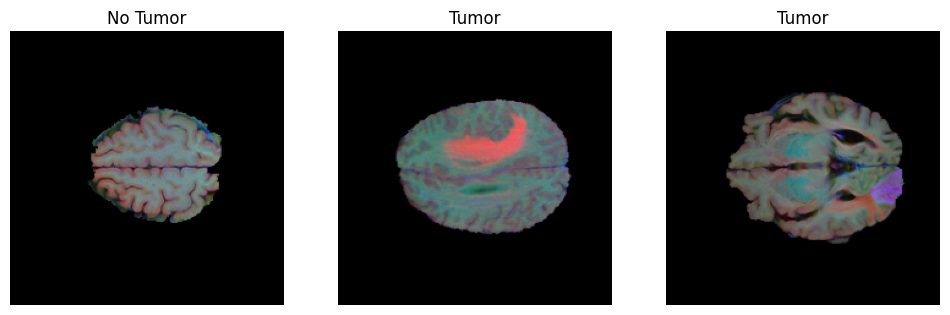

In [47]:
images, labels_batch = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels_batch.shape)

plt.figure(figsize=(12,4))

for i in range(3):
    img = inverse_imagenet_normalize(images[i])
    img = img.permute(1, 2, 0).numpy()

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title("Tumor" if labels_batch[i].item() == 1 else "No Tumor")
    plt.axis("off")

plt.show()

Data is loaded batch by batch from disk using PyTorch DataLoader. The full dataset is not loaded into RAM.

Chuyển model train sang PyTorch

Build MobileNetV2 model

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.last_channel, 2)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Device: cuda


Training and evaluation functions

In [29]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [30]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return (
        epoch_loss,
        epoch_acc,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )

Train MobileNetV2

In [31]:
EPOCHS = 100

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
save_path = "/content/drive/MyDrive/Brain_Tumor_Project/best_mobilenetv2_pytorch.pth"

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc, y_true, y_pred, y_prob = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print("Best model saved.")

100%|██████████| 224/224 [01:50<00:00,  2.03it/s]


Epoch [1/5]
Train Loss: 0.2127 | Train Acc: 0.9080
Val Loss: 0.1498 | Val Acc: 0.9424
Best model saved.


100%|██████████| 224/224 [01:45<00:00,  2.12it/s]


Epoch [2/5]
Train Loss: 0.1209 | Train Acc: 0.9539
Val Loss: 0.1266 | Val Acc: 0.9509
Best model saved.


100%|██████████| 224/224 [01:41<00:00,  2.21it/s]


Epoch [3/5]
Train Loss: 0.0828 | Train Acc: 0.9688
Val Loss: 0.1397 | Val Acc: 0.9482


100%|██████████| 224/224 [01:40<00:00,  2.23it/s]


Epoch [4/5]
Train Loss: 0.0528 | Train Acc: 0.9803
Val Loss: 0.1158 | Val Acc: 0.9590
Best model saved.


100%|██████████| 224/224 [02:17<00:00,  1.63it/s]

Epoch [5/5]
Train Loss: 0.0368 | Train Acc: 0.9865
Val Loss: 0.1461 | Val Acc: 0.9534


Plot training curves

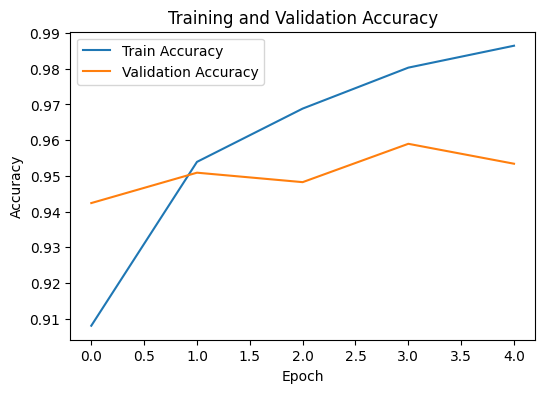

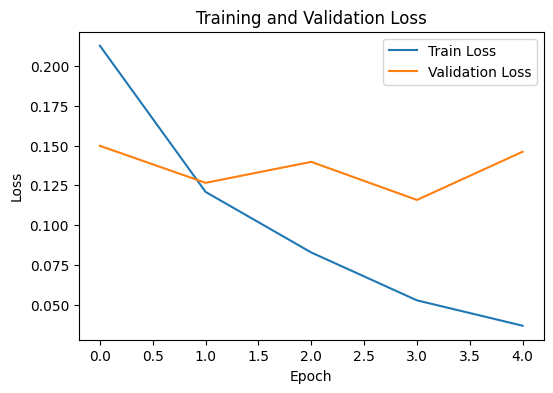

In [32]:
plt.figure(figsize=(6,4))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Evaluate MobileNetV2

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

val_loss, val_acc, y_true, y_pred, y_prob = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(classification_report(
    y_true,
    y_pred,
    target_names=["No Tumor", "Tumor"]
))

cm = confusion_matrix(y_true, y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel()

cnn_acc = accuracy_score(y_true, y_pred)
cnn_precision = precision_score(y_true, y_pred)
cnn_recall = recall_score(y_true, y_pred)
cnn_f1 = f1_score(y_true, y_pred)
cnn_specificity = tn / (tn + fp)
cnn_auc = roc_auc_score(y_true, y_prob)

print("CNN Accuracy:", cnn_acc)
print("CNN Precision:", cnn_precision)
print("CNN Recall/Sensitivity:", cnn_recall)
print("CNN Specificity:", cnn_specificity)
print("CNN F1:", cnn_f1)
print("CNN AUC:", cnn_auc)

100%|██████████| 224/224 [01:44<00:00,  2.14it/s]

              precision    recall  f1-score   support

    No Tumor       0.96      0.95      0.96      4097
       Tumor       0.94      0.95      0.95      3069

    accuracy                           0.95      7166
   macro avg       0.95      0.95      0.95      7166
weighted avg       0.95      0.95      0.95      7166

[[3906  191]
 [ 143 2926]]
CNN Accuracy: 0.9533910131174993
CNN Precision: 0.9387231312159128
CNN Recall/Sensitivity: 0.953405017921147
CNN Specificity: 0.9533805223334147
CNN F1: 0.9460071128354348
CNN AUC: 0.9892367341877998


Confusion matrix

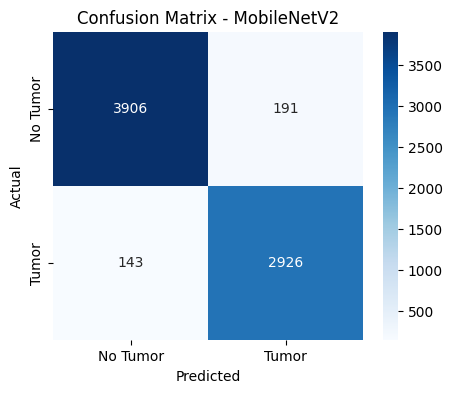

In [35]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Tumor", "Tumor"],
    yticklabels=["No Tumor", "Tumor"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MobileNetV2")
plt.show()

Extract deep features

In [36]:
feature_extractor = model.features.to(device)
feature_extractor.eval()

def extract_features(loader):
    features = []
    labels_list = []

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)

            x = feature_extractor(images)
            x = nn.functional.adaptive_avg_pool2d(x, (1, 1))
            x = torch.flatten(x, 1)

            features.append(x.cpu().numpy())
            labels_list.append(labels.numpy())

    features = np.concatenate(features, axis=0)
    labels_list = np.concatenate(labels_list, axis=0)

    return features, labels_list

In [37]:
train_features, train_labels = extract_features(train_loader)
test_features, test_labels = extract_features(test_loader)

print("Train features:", train_features.shape)
print("Test features:", test_features.shape)

100%|██████████| 224/224 [01:39<00:00,  2.25it/s]

Train features: (28660, 1280)
Test features: (7166, 1280)


PCA + SVM

In [38]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(train_features)
X_test_pca = pca.transform(test_features)

print("Before PCA:", train_features.shape)
print("After PCA:", X_train_pca.shape)
print("Explained variance:", np.sum(pca.explained_variance_ratio_))

Before PCA: (28660, 1280)
After PCA: (28660, 50)
Explained variance: 0.91541356


In [39]:
svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train_pca, train_labels)

svm_pred = svm.predict(X_test_pca)
svm_prob = svm.predict_proba(X_test_pca)[:, 1]

Evaluate PCA + SVM

In [40]:
print(classification_report(
    test_labels,
    svm_pred,
    target_names=["No Tumor", "Tumor"]
))

cm_svm = confusion_matrix(test_labels, svm_pred)
print(cm_svm)

tn, fp, fn, tp = cm_svm.ravel()

pca_acc = accuracy_score(test_labels, svm_pred)
pca_precision = precision_score(test_labels, svm_pred)
pca_recall = recall_score(test_labels, svm_pred)
pca_f1 = f1_score(test_labels, svm_pred)
pca_specificity = tn / (tn + fp)
pca_auc = roc_auc_score(test_labels, svm_prob)

print("PCA-SVM Accuracy:", pca_acc)
print("PCA-SVM Precision:", pca_precision)
print("PCA-SVM Recall/Sensitivity:", pca_recall)
print("PCA-SVM Specificity:", pca_specificity)
print("PCA-SVM F1:", pca_f1)
print("PCA-SVM AUC:", pca_auc)

              precision    recall  f1-score   support

    No Tumor       0.96      0.97      0.97      4097
       Tumor       0.96      0.95      0.95      3069

    accuracy                           0.96      7166
   macro avg       0.96      0.96      0.96      7166
weighted avg       0.96      0.96      0.96      7166

[[3986  111]
 [ 165 2904]]
PCA-SVM Accuracy: 0.961484789282724
PCA-SVM Precision: 0.96318407960199
PCA-SVM Recall/Sensitivity: 0.946236559139785
PCA-SVM Specificity: 0.9729070051257017
PCA-SVM F1: 0.9546351084812623
PCA-SVM AUC: 0.9785124783943747


Final comparison table

In [43]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Fine-tuned MobileNetV2",
        "MobileNetV2 Features + PCA + SVM"
    ],
    "Accuracy": [cnn_acc, pca_acc],
    "Precision": [cnn_precision, pca_precision],
    "Recall/Sensitivity": [cnn_recall, pca_recall],
    "Specificity": [cnn_specificity, pca_specificity],
    "F1-score": [cnn_f1, pca_f1],
    "AUC": [cnn_auc, pca_auc]
})

results

,Model,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,AUC
0,Fine-tuned MobileNetV2,0.953391,0.938723,0.953405,0.953381,0.946007,0.989237
1,MobileNetV2 Features + PCA + SVM,0.961485,0.963184,0.946237,0.972907,0.954635,0.978512


In [44]:
results.to_csv(
    "/content/drive/MyDrive/Brain_Tumor_Project/pytorch_results.csv",
    index=False
)